# Approach 1 — guided design with the finalized surrogate + oracle

Property-guided FP design wired to the models trained in `finalize_models.ipynb`:

- **Surrogate** (MLP-max, `trained_models/surrogate_net.pt`) — *guides* the masked refinement.
- **Oracle** (CNN-max, `trained_models/oracle_net.pt`) — independent *evaluator* (different architecture +
  different random split → decorrelated; test em-max MAE ~14 nm).

Both are `fp_models.SpectrumNet` on per-residue ESM-2 embeddings (max pooling). The loop scores candidates with
the surrogate (`z(log p_ESM) - lam * z(g-error)`, restricted to ESM's top-k) and judges designs with the oracle.

## 0. Setup + models

In [1]:
import csv, os, numpy as np, torch
import arcadia_pycolor as apc
import fp_models as fpm
try:
    import matplotlib.pyplot as plt; HAVE_PLT=True; apc.mpl.setup()
except Exception: HAVE_PLT=False
TD="training_data"; DS=os.path.join("..","fpbase-extractor","processed_data","ESM-spectrum")
dev=torch.device("mps") if (getattr(torch.backends,"mps",None) and torch.backends.mps.is_available()) \
    else (torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu"))
rows=list(csv.DictReader(open(os.path.join(TD,"split_assignments.csv")))); N=len(rows)
Y=np.load(os.path.join(TD,"spectra.npy")).astype(np.float32); grid=np.load(os.path.join(DS,"grid_nm.npy")); G=len(grid)
EMM=np.array([float(r["em_max"]) for r in rows]); EXM=np.array([float(r["ex_max"]) for r in rows])
cluster=np.array([int(r["cluster"]) for r in rows])
seqs=[None]*N; h=None
for line in open(os.path.join(TD,"sequences.fasta")):
    line=line.strip()
    if line.startswith(">"): h=int(line[1:].split("|")[0])
    elif line: seqs[h]=line
print("device",dev,"| N",N)

device mps | N 453


In [2]:
# load finalized surrogate (guide) + oracle (evaluator); both reconstruct from their saved config
surrogate_net, s_meta = fpm.load_model(os.path.join("trained_models","surrogate_net.pt"), dev, out=2*G)
oracle_net,    o_meta = fpm.load_model(os.path.join("trained_models","oracle_net.pt"),    dev, out=2*G)
print(f"surrogate: {s_meta['arch']}-{s_meta['pool']} | test MSE {s_meta['test_mse']:.4f}")
print(f"oracle:    {o_meta['arch']}-{o_meta['pool']} | test MSE {o_meta['test_mse']:.4f}")

# spectrum predictors on novel sequences (embed per-residue with ESM-2, then run the net)
g_spectrum      = fpm.spectrum_fn(surrogate_net, dev)   # GUIDANCE
oracle_spectrum = fpm.spectrum_fn(oracle_net, dev)      # EVALUATION

esm_model, alphabet, bc = fpm.get_esm(dev)              # also used for masked-LM logits + pseudo-perplexity
AA_MASK = torch.zeros(len(alphabet.all_toks), dtype=torch.bool)
for a in "ACDEFGHIKLMNPQRSTVWY": AA_MASK[alphabet.get_idx(a)] = True
AA_MASK = AA_MASK.to(dev)
SPECIAL = {alphabet.cls_idx, alphabet.eos_idx, alphabet.padding_idx, alphabet.mask_idx}

surrogate: MLP-max | test MSE 0.0308
oracle:    CNN-max | test MSE 0.0215


## 1. Pseudo-perplexity (naturalness)

In [3]:
@torch.no_grad()
def pseudo_perplexity(seq, batch_size=32):
    _,_,base=bc([("s",seq.strip().upper())]); base=base[0].to(dev)
    res=[i for i,t in enumerate(base.tolist()) if t not in SPECIAL]; tot=0.0
    for s in range(0,len(res),batch_size):
        ch=res[s:s+batch_size]; bt=base.unsqueeze(0).repeat(len(ch),1).clone()
        for r,p in enumerate(ch): bt[r,p]=alphabet.mask_idx
        lp=torch.log_softmax(esm_model(bt)["logits"],dim=-1)
        for r,p in enumerate(ch): tot+=float(lp[r,p,base[p]])
    n=len(res); return tot, float(np.exp(-tot/n))

## 2. Guided refinement (surrogate guides, oracle evaluates)

In [4]:
def to_tokens(seq): _,_,t=bc([("q",seq.strip().upper())]); return t.to(dev)
def tokens_to_seq(t1d): return "".join(alphabet.get_tok(int(x)) for x in t1d if int(x) not in SPECIAL)

@torch.no_grad()
def guided_refine(seq, target, n_sweeps=1, k=6, lam=5.0, temperature=0.0, editable=None, eval_fn=None, verbose=True):
    toks=to_tokens(seq)
    res=[i for i,t in enumerate(toks[0].tolist()) if t not in SPECIAL]
    if editable is not None: res=[res[j] for j in editable]
    tnorm=float(torch.sum(target**2))+1e-8; trace=[]
    for sweep in range(n_sweeps):
        for pos in res:
            toks[0,pos]=alphabet.mask_idx
            lg=esm_model(toks)["logits"][0,pos].masked_fill(~AA_MASK,float("-inf"))
            logp=torch.log_softmax(lg,-1); topv,topi=torch.topk(logp,k)
            cand=[]
            for idx in topi.tolist(): toks[0,pos]=idx; cand.append(tokens_to_seq(toks[0]))
            d=torch.sum((g_spectrum(cand)-target.unsqueeze(0))**2,1)/tnorm          # surrogate guidance
            lpz=(topv-topv.mean())/(topv.std()+1e-6); dz=(d-d.mean())/(d.std()+1e-6)
            scores=lpz-lam*dz
            ch=(torch.multinomial(torch.softmax(scores/temperature,-1),1).item() if temperature>0 else int(torch.argmax(scores)))
            toks[0,pos]=int(topi[ch].item())
        cur=tokens_to_seq(toks[0])
        ev=(eval_fn(cur)[0] if eval_fn is not None else g_spectrum(cur)[0])           # oracle evaluation
        err=float(torch.sum((ev-target)**2)/tnorm); trace.append(err)
        if verbose: print(f"  sweep {sweep}: oracle error {err:.4f}")
    return tokens_to_seq(toks[0]), trace

## 3. Design demo: re-design a scaffold toward target spectra

Local re-design: start from a GFP scaffold and edit a residue window toward target spectra spanning the color
range; success is **oracle-judged** (draft → refined). Knobs exposed; a generic editable window is used (target
chromophore-region positions to do better).

In [5]:
N_TARGETS=3; N_SWEEPS=1; K_TOP=6; LAM=5.0; WINDOW=40

# scaffold = a green FP of typical length
greens=np.where(np.abs(EMM-510)<15)[0]
scaffold_idx=int(greens[np.argmin(np.abs(np.array([len(seqs[i]) for i in greens])-240))])
scaffold=seqs[scaffold_idx]; L=len(scaffold); mid=L//2
editable=list(range(max(0,mid-WINDOW//2), min(L,mid+WINDOW//2)))
print(f"scaffold: {rows[scaffold_idx]['name']} (len {L}, em {EMM[scaffold_idx]:.0f})")

# targets spanning emission: nearest FPs to blue/green/red
# LOCAL targets: spectra within +/-60 nm of the scaffold (the regime this in-distribution surrogate is valid for)
sem=EMM[scaffold_idx]
_cand=sorted([i for i in range(N) if i!=scaffold_idx and abs(EMM[i]-sem)<=60], key=lambda i: EMM[i])
target_idx=[_cand[int(x)] for x in np.linspace(0,len(_cand)-1,N_TARGETS)]
res=[]
for i in target_idx:
    tspec=torch.tensor(Y[i],device=dev); tnorm=float(torch.sum(tspec**2))+1e-8
    d0=float(torch.sum((oracle_spectrum(scaffold)[0]-tspec)**2)/tnorm)
    des,_=guided_refine(scaffold,tspec,n_sweeps=N_SWEEPS,k=K_TOP,lam=LAM,editable=editable,eval_fn=oracle_spectrum,verbose=False)
    d1=float(torch.sum((oracle_spectrum(des)[0]-tspec)**2)/tnorm); _,ppl=pseudo_perplexity(des)
    res.append(dict(idx=i,name=rows[i]["name"],em=EMM[i],draft=d0,refined=d1,ppl=ppl,design=des))
    print(f"target {rows[i]['name'][:18]:18s} (em {EMM[i]:.0f}) | oracle err {d0:.3f} -> {d1:.3f} | ppl {ppl:.2f}")
print(f"\nmean oracle error: draft {np.mean([r['draft'] for r in res]):.3f} -> refined {np.mean([r['refined'] for r in res]):.3f}")

scaffold: rsEGFP (len 239, em 510)


target Sumire             (em 414) | oracle err 1.700 -> 1.393 | ppl 15.07


target mOrange2           (em 565) | oracle err 1.523 -> 1.262 | ppl 16.05


target iRFP720            (em 720) | oracle err 1.669 -> 1.461 | ppl 15.67

mean oracle error: draft 1.630 -> refined 1.372


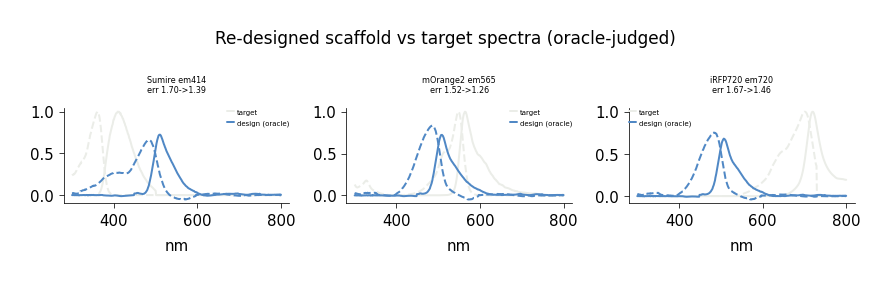

In [6]:
if HAVE_PLT:
    n=len(res); fig,ax=plt.subplots(1,n,figsize=(4*n,3.4),squeeze=False)
    for c,r in enumerate(res):
        t=Y[r["idx"]]; rs=oracle_spectrum(r["design"])[0].cpu().numpy()
        a=ax[0,c]
        a.plot(grid,t[:G],color=apc.gray,ls="--"); a.plot(grid,t[G:],color=apc.gray,ls="-",label="target")
        a.plot(grid,rs[:G],color=apc.aegean,ls="--"); a.plot(grid,rs[G:],color=apc.aegean,ls="-",label="design (oracle)")
        a.set_title(f"{r['name'][:16]} em{r['em']:.0f}\nerr {r['draft']:.2f}->{r['refined']:.2f}",fontsize=8)
        a.set_xlabel("nm"); a.legend(fontsize=7)
    plt.suptitle("Re-designed scaffold vs target spectra (oracle-judged)"); plt.tight_layout(); plt.show()

## Notes
- Models come from `finalize_models.ipynb`; re-run that to refresh `trained_models/{surrogate,oracle}_net.pt`.
- Guidance uses the surrogate; the oracle (different architecture + split) judges. Keep designs on-manifold
  (low pseudo-perplexity) — the oracle is validated on natural FPs, so its verdict is least reliable for
  off-manifold designs. A generic edit window limits big color shifts; target chromophore positions to improve.